In [3]:
import os
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams

# 设置中文字体（解决乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# ==================== 新增：统一分析函数（支持多模型） ====================
def analyze_failures_multi(models, test_images_dir, labels_dir, conf_threshold=0.25, iou_threshold=0.5, max_images=None):
    """
    同时分析多个模型（如基线模型和改进模型）的失败案例。
    参数：
        models: 字典，键为模型名称（如 'baseline', 'improved'），值为 YOLO 模型实例
        其他参数同原 analyze_failures
    返回：
        results: 字典，包含每个模型的统计信息以及每张图像的详细预测结果，便于后续对比
    """
    test_images = sorted(Path(test_images_dir).glob('*.jpg')) + sorted(Path(test_images_dir).glob('*.png'))
    if max_images is not None:
        test_images = test_images[:max_images]

    labels_dir = Path(labels_dir)
    model_names = list(models.keys())
    
    # 初始化每个模型的统计
    stats = {name: {'tp': 0, 'fp': 0, 'fn': 0} for name in model_names}
    # 存储每张图像的详细信息
    per_image = {}  # key: 图像文件名, value: {model_name: {'tp','fp','fn','pred_boxes','gt_boxes'}}
    
    for img_path in test_images:
        # 读取真实标签（与之前相同）
        label_file = labels_dir / img_path.with_suffix('.txt').name
        gt_boxes = []
        if label_file.exists():
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        xc, yc, w, h = map(float, parts[1:])
                        # 先读取图像尺寸（只读一次，可以共享）
                        img = cv2.imread(str(img_path))
                        if img is None:
                            continue
                        img_h, img_w = img.shape[:2]
                        x1 = (xc - w/2) * img_w
                        y1 = (yc - h/2) * img_h
                        x2 = (xc + w/2) * img_w
                        y2 = (yc + h/2) * img_h
                        gt_boxes.append([x1, y1, x2, y2, class_id])
        else:
            print(f"警告: {label_file} 不存在，跳过该图像")
            continue
        
        # 对每个模型进行推理并计算 TP/FP/FN
        per_image[img_path.name] = {'gt_boxes': gt_boxes, 'gt_count': len(gt_boxes)}
        for name, model in models.items():
            results = model(str(img_path), conf=conf_threshold)
            pred_boxes = []
            if results[0].boxes is not None:
                for box in results[0].boxes:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    conf = box.conf[0].item()
                    class_id = int(box.cls[0].item())
                    pred_boxes.append([x1, y1, x2, y2, conf, class_id])
            
            # 计算 TP, FP, FN（逻辑同原函数）
            pred_boxes.sort(key=lambda x: x[4], reverse=True)
            gt_matched = [False] * len(gt_boxes)
            tp = 0
            fp = 0
            for pred in pred_boxes:
                pred_box = pred[:4]
                best_iou = 0
                best_gt_idx = -1
                for i, gt in enumerate(gt_boxes):
                    if gt_matched[i]:
                        continue
                    # 计算 IoU
                    xA = max(pred_box[0], gt[0])
                    yA = max(pred_box[1], gt[1])
                    xB = min(pred_box[2], gt[2])
                    yB = min(pred_box[3], gt[3])
                    interArea = max(0, xB - xA) * max(0, yB - yA)
                    if interArea == 0:
                        iou = 0
                    else:
                        boxAArea = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
                        boxBArea = (gt[2] - gt[0]) * (gt[3] - gt[1])
                        iou = interArea / float(boxAArea + boxBArea - interArea)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = i
                if best_iou >= iou_threshold:
                    tp += 1
                    gt_matched[best_gt_idx] = True
                else:
                    fp += 1
            fn = len(gt_boxes) - sum(gt_matched)
            
            # 更新统计
            stats[name]['tp'] += tp
            stats[name]['fp'] += fp
            stats[name]['fn'] += fn
            # 存储该模型的预测详情
            per_image[img_path.name][name] = {
                'tp': tp, 'fp': fp, 'fn': fn,
                'pred_boxes': pred_boxes,
                'pred_count': len(pred_boxes)
            }
    
    # 计算每个模型的精确率、召回率、F1
    for name in model_names:
        tp = stats[name]['tp']
        fp = stats[name]['fp']
        fn = stats[name]['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        stats[name]['precision'] = precision
        stats[name]['recall'] = recall
        stats[name]['f1'] = f1
    
    return {'stats': stats, 'per_image': per_image}

def find_comparison_cases_multi(analysis_result, model_names, focus_model=None):
    """
    从多模型分析结果中筛选出多种错误类型。
    
    参数：
        analysis_result: analyze_failures_multi 的返回结果
        model_names: 要参与对比的模型名称列表，例如 ['baseline', 'improved', 'improved_adamw']
        focus_model: 可选，指定一个关注模型（如 'improved'），用于筛选“仅该模型有错误而其他都正确”的案例
    
    返回：
        dict: {
            'all_error': [img_name1, ...],           # 所有模型都有错误
            'only_focus_error': [img_name2, ...],    # 仅 focus_model 有错误（其他都正确）
            'any_error': [...],                       # 至少一个模型有错误（可用于进一步筛选）
        }
    """
    per_image = analysis_result['per_image']
    results = {'all_error': [], 'only_focus_error': [], 'any_error': []}
    
    for img_name, data in per_image.items():
        gt_count = data['gt_count']
        # 获取每个模型的错误状态
        error_status = {}
        for name in model_names:
            mdata = data.get(name)
            if mdata is None:
                continue
            has_error = (mdata['tp'] < gt_count) or (mdata['fp'] > 0)
            error_status[name] = has_error
        
        # 所有模型都有错误
        if all(error_status.values()):
            results['all_error'].append(img_name)
        
        # 至少一个模型有错误
        if any(error_status.values()):
            results['any_error'].append(img_name)
        
        # 仅 focus_model 有错误（如果指定了 focus_model）
        if focus_model is not None:
            only_focus = error_status.get(focus_model, False) and \
                         all(not error_status.get(n, True) for n in model_names if n != focus_model)
            if only_focus:
                results['only_focus_error'].append(img_name)
    
    return results

def visualize_comparison_multi(models, image_name, test_images_dir, labels_dir, conf_threshold=0.25):
    """
    展示多个模型（三个或更多）的预测结果对比。
    
    参数：
        models: 字典，键为模型名称（如 'baseline', 'improved', 'improved_adamw'），值为 YOLO 模型实例
        image_name: 图像文件名
        test_images_dir, labels_dir: 路径
        conf_threshold: 置信度阈值
    """
    img_path = Path(test_images_dir) / image_name
    if not img_path.exists():
        print(f"图像不存在: {img_path}")
        return
    label_path = Path(labels_dir) / img_path.with_suffix('.txt').name
    
    # 读取图像
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # 读取真实框
    gt_boxes = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    xc, yc, w, h = map(float, parts[1:])
                    x1 = (xc - w/2) * img_w
                    y1 = (yc - h/2) * img_h
                    x2 = (xc + w/2) * img_w
                    y2 = (yc + h/2) * img_h
                    gt_boxes.append([x1, y1, x2, y2])
    
    # 模型数量
    num_models = len(models)
    # 总子图数 = 真实框 + 模型数
    total_cols = 1 + num_models
    fig, axes = plt.subplots(1, total_cols, figsize=(6 * total_cols, 6))
    if total_cols == 1:
        axes = [axes]
    
    # 定义颜色列表（用于不同模型的预测框）
    model_colors = ['red', 'orange', 'blue', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    # 第一列：真实框
    ax_gt = axes[0]
    ax_gt.imshow(img)
    for (x1, y1, x2, y2) in gt_boxes:
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='green', facecolor='none')
        ax_gt.add_patch(rect)
    ax_gt.set_title(f'真实框 (共 {len(gt_boxes)} 个)', fontsize=24)
    ax_gt.axis('off')
    
    # 后续列：每个模型一个子图
    for idx, (name, model) in enumerate(models.items()):
        ax = axes[idx + 1]
        ax.imshow(img)
        results = model(str(img_path), conf=conf_threshold)
        pred_boxes = []
        if results[0].boxes is not None:
            color = model_colors[idx % len(model_colors)]
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f'{conf:.2f}', color=color, fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
                pred_boxes.append([x1, y1, x2, y2, conf])
        ax.set_title(f'{name} (共 {len(pred_boxes)} 个)', fontsize=24)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()



image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000001682.jpg: 352x512 1 ship, 60.2ms
Speed: 2.4ms preprocess, 60.2ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000001682.jpg: 352x512 1 ship, 33.4ms
Speed: 1.2ms preprocess, 33.4ms inference, 2.1ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000001682.jpg: 352x512 1 ship, 20.7ms
Speed: 1.0ms preprocess, 20.7ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 2 ships, 10.2ms
Speed: 1.3ms preprocess, 10.2ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 3 ships, 20.1ms
Speed: 1.1ms preprocess, 20.1ms inference, 1.5ms postpr

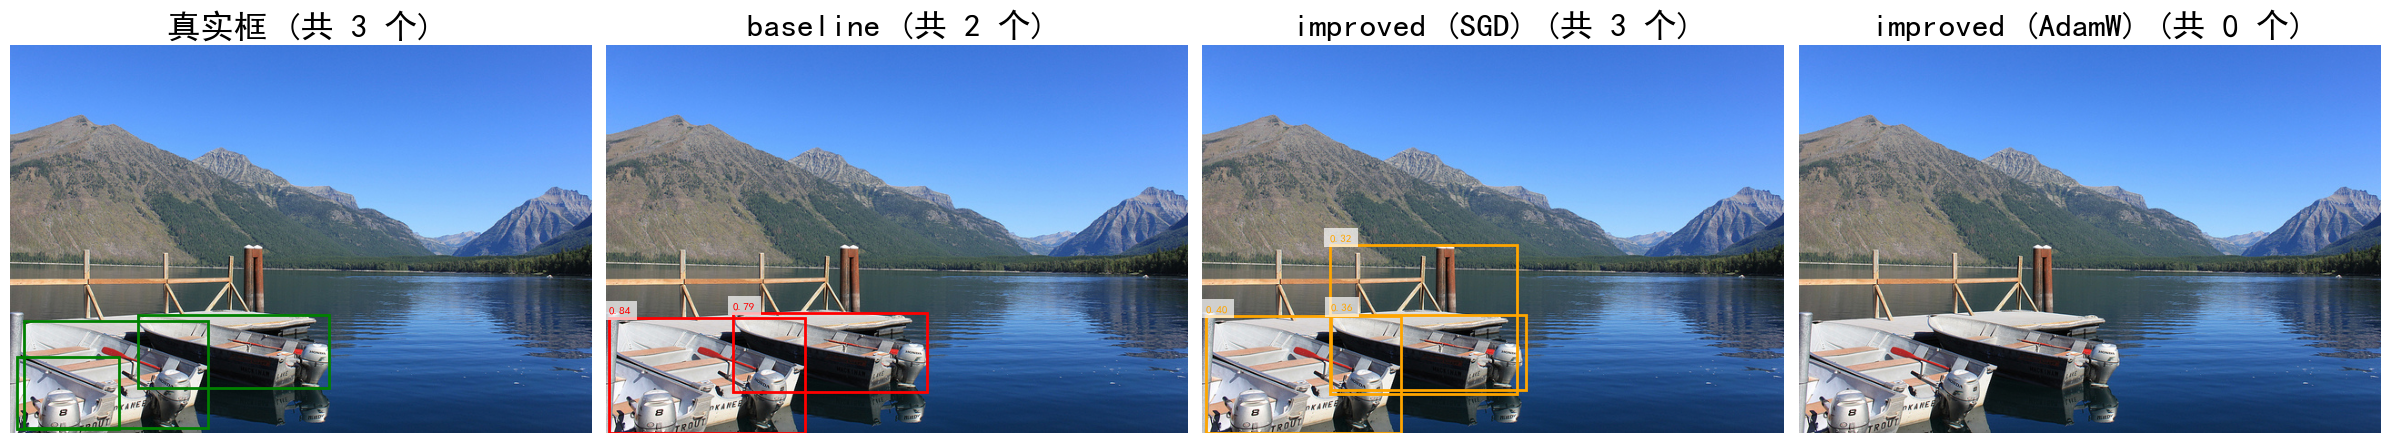


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 2 ships, 12.0ms
Speed: 1.5ms preprocess, 12.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 2 ships, 23.1ms
Speed: 1.1ms preprocess, 23.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 1 ship, 22.3ms
Speed: 1.1ms preprocess, 22.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 512)


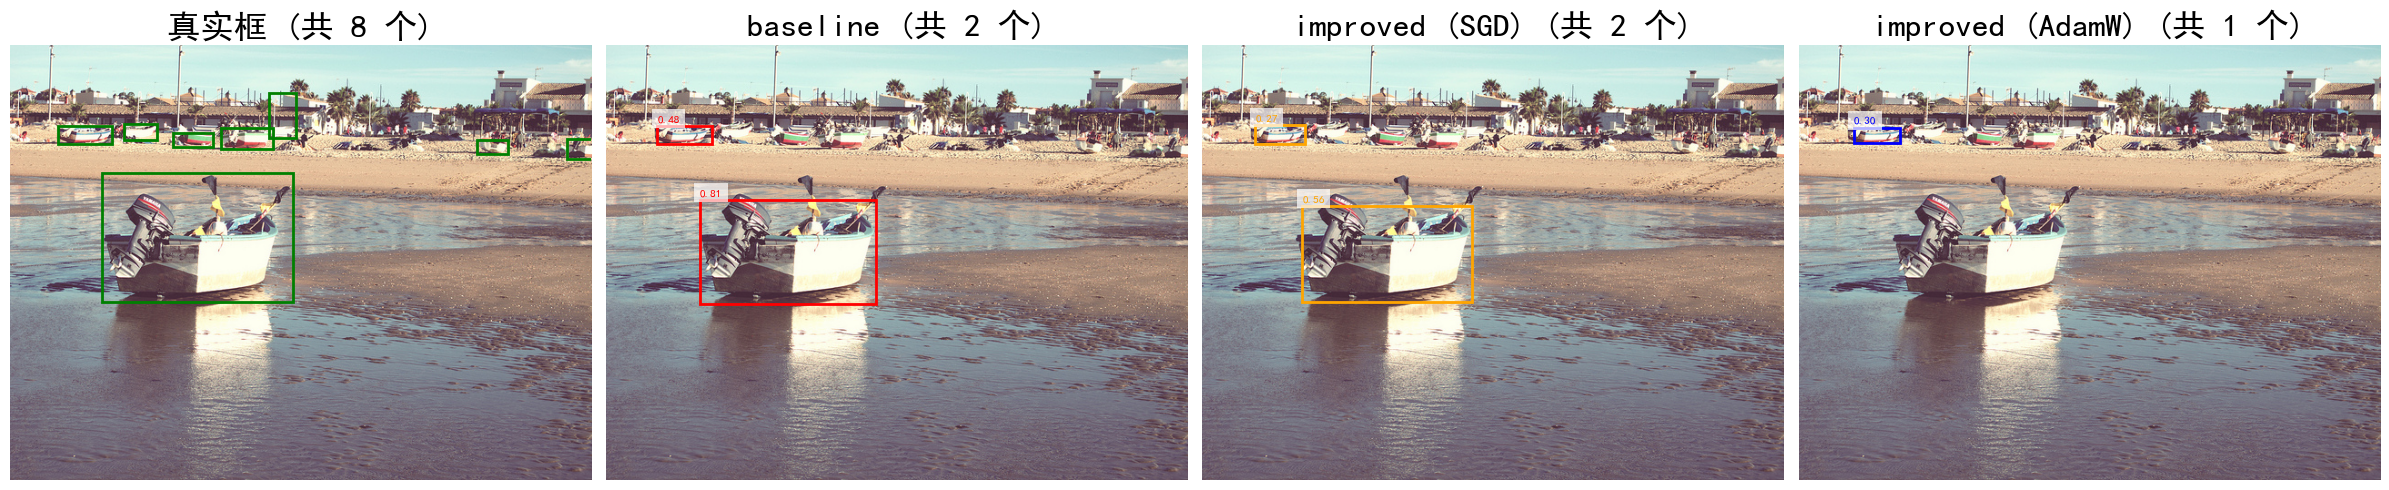


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 3 ships, 10.6ms
Speed: 1.1ms preprocess, 10.6ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 3 ships, 21.4ms
Speed: 1.1ms preprocess, 21.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 1 ship, 22.1ms
Speed: 1.4ms preprocess, 22.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)


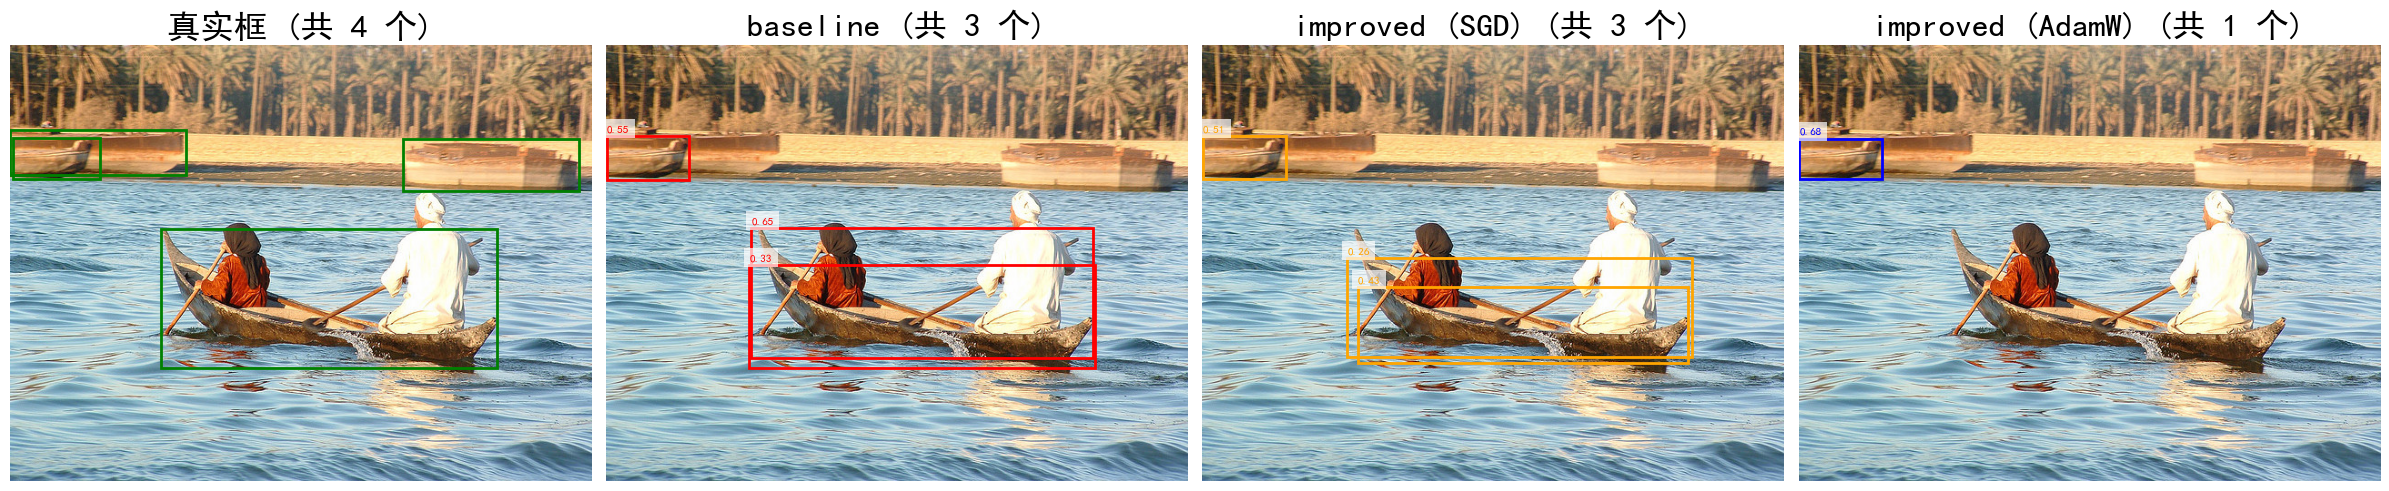


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 11.4ms
Speed: 1.7ms preprocess, 11.4ms inference, 0.6ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 21.9ms
Speed: 1.4ms preprocess, 21.9ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 20.4ms
Speed: 1.2ms preprocess, 20.4ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 512)


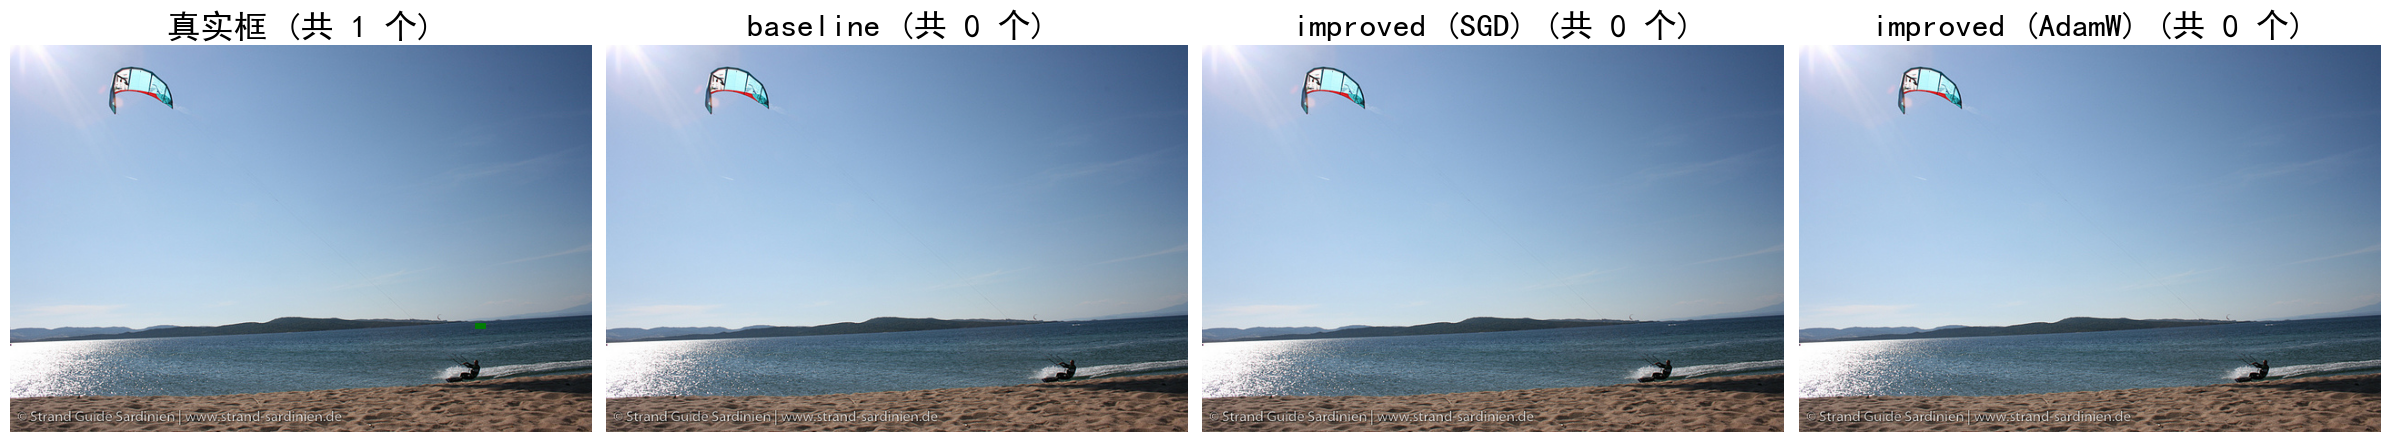


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 6 ships, 10.2ms
Speed: 1.3ms preprocess, 10.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 3 ships, 22.6ms
Speed: 1.1ms preprocess, 22.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 1 ship, 22.6ms
Speed: 1.1ms preprocess, 22.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)


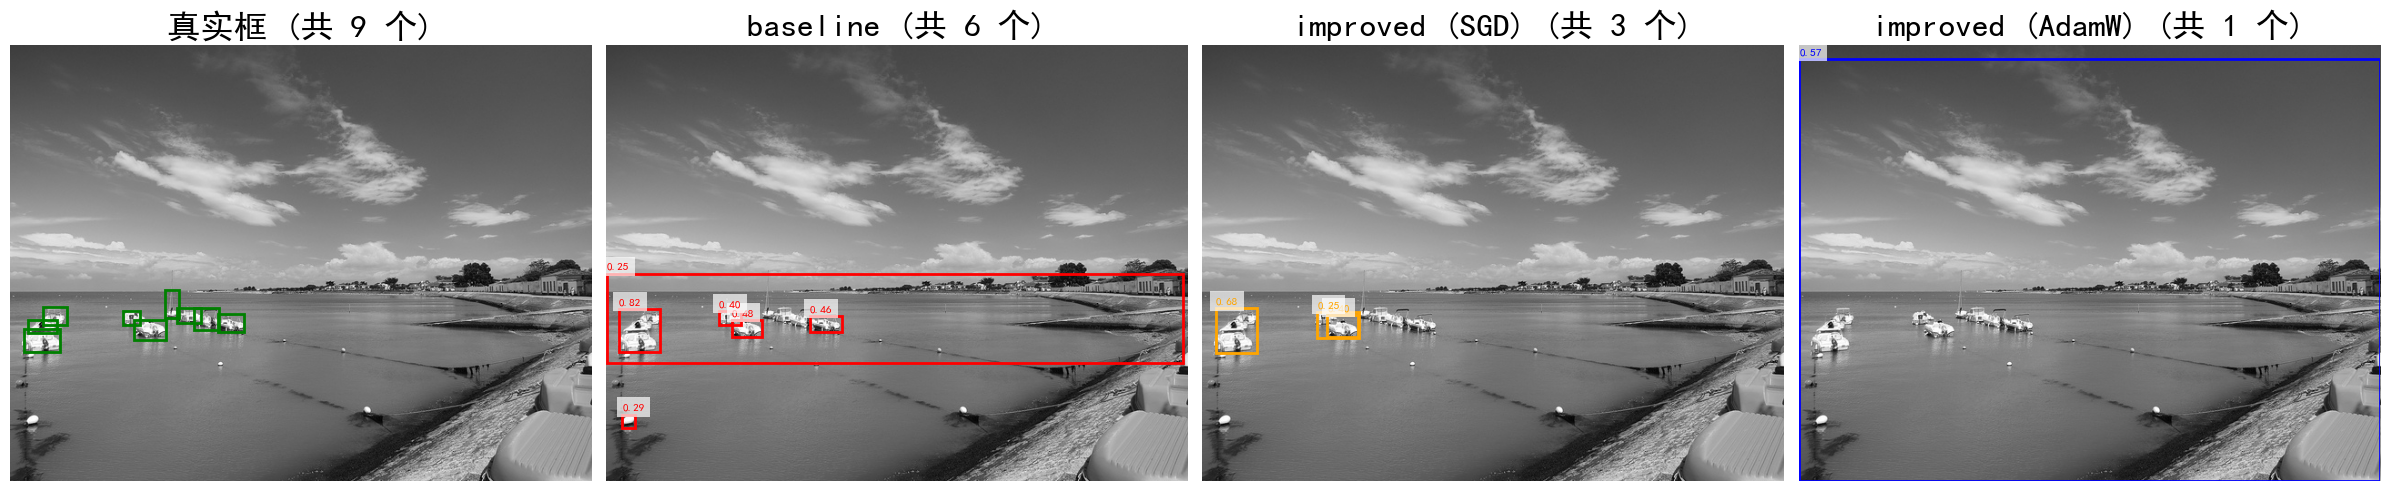


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000005237.jpg: 288x512 23 ships, 10.3ms
Speed: 1.1ms preprocess, 10.3ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000005237.jpg: 288x512 2 ships, 20.0ms
Speed: 1.3ms preprocess, 20.0ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000005237.jpg: 288x512 2 ships, 20.2ms
Speed: 1.2ms preprocess, 20.2ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 512)


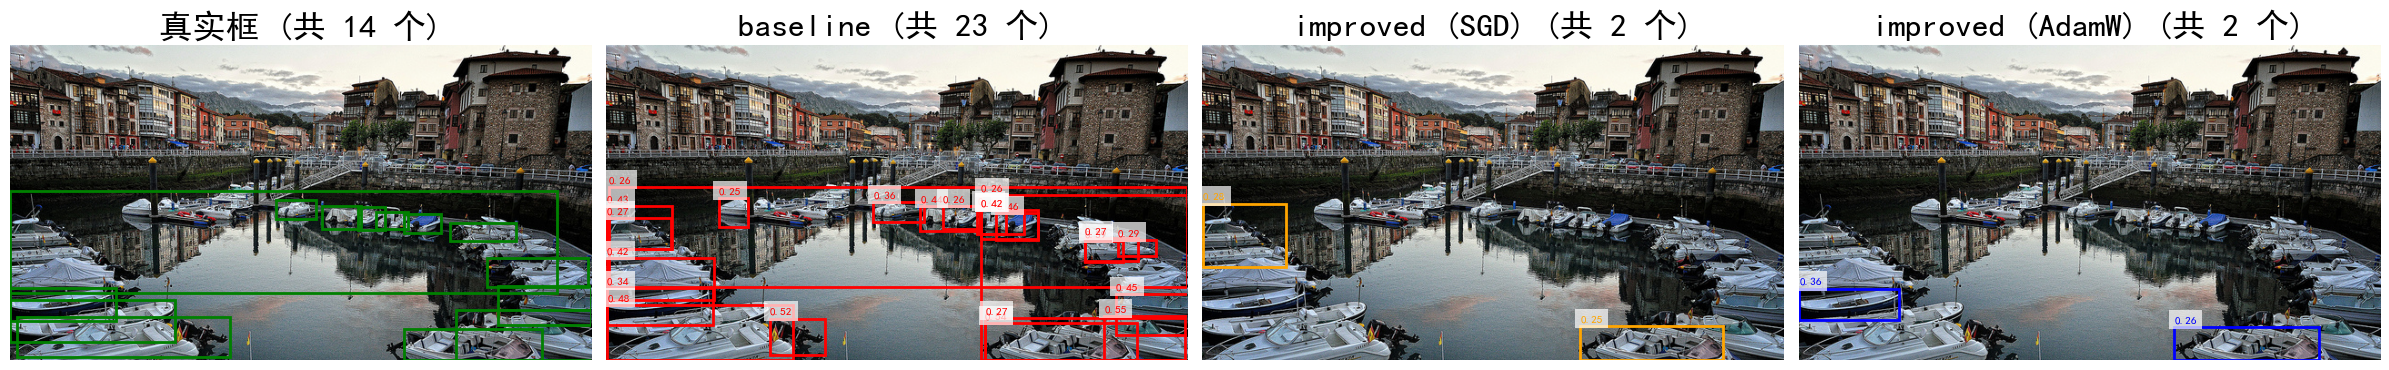


=== 任意模型错误的案例 ===

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 2 ships, 13.1ms
Speed: 1.4ms preprocess, 13.1ms inference, 2.5ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 3 ships, 28.5ms
Speed: 1.0ms preprocess, 28.5ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 (no detections), 28.8ms
Speed: 1.1ms preprocess, 28.8ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 512)


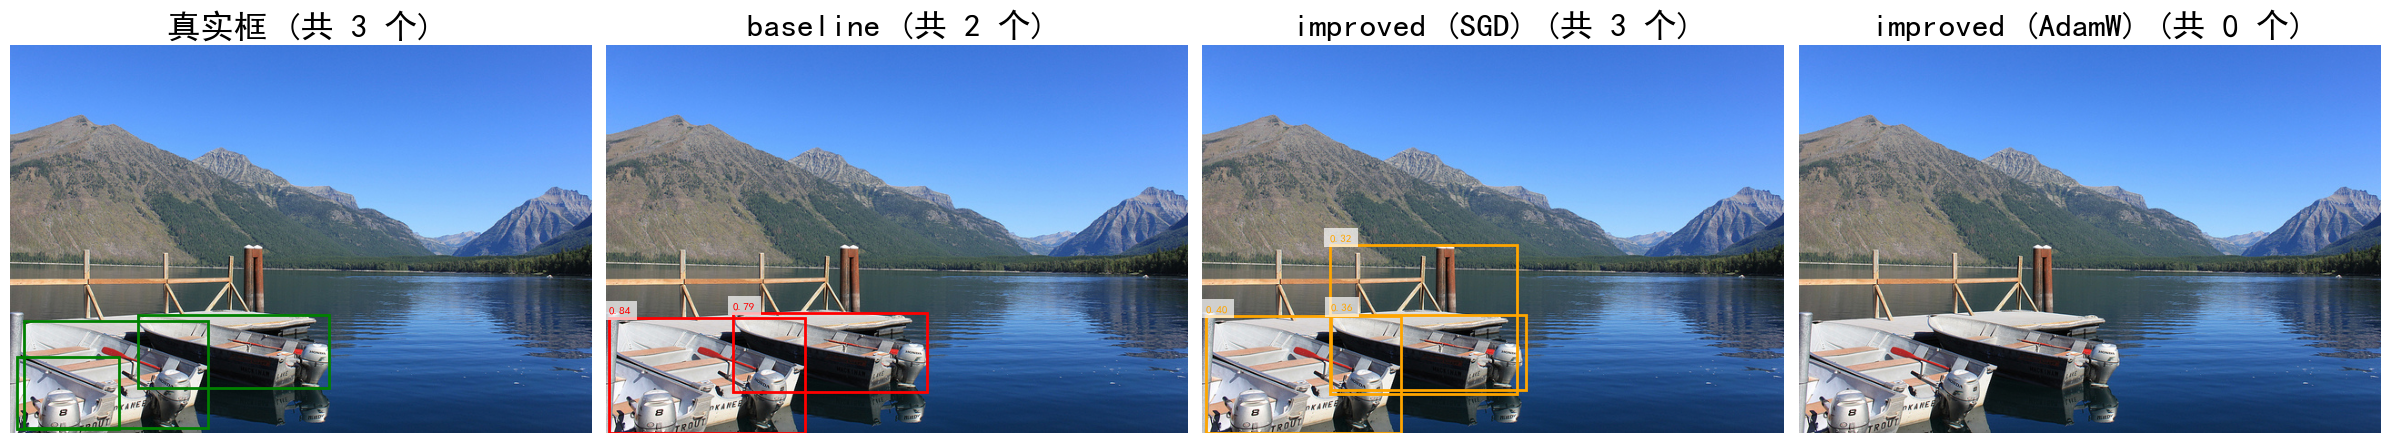


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 2 ships, 14.2ms
Speed: 1.3ms preprocess, 14.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 2 ships, 33.6ms
Speed: 1.3ms preprocess, 33.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 1 ship, 33.8ms
Speed: 1.2ms preprocess, 33.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 512)


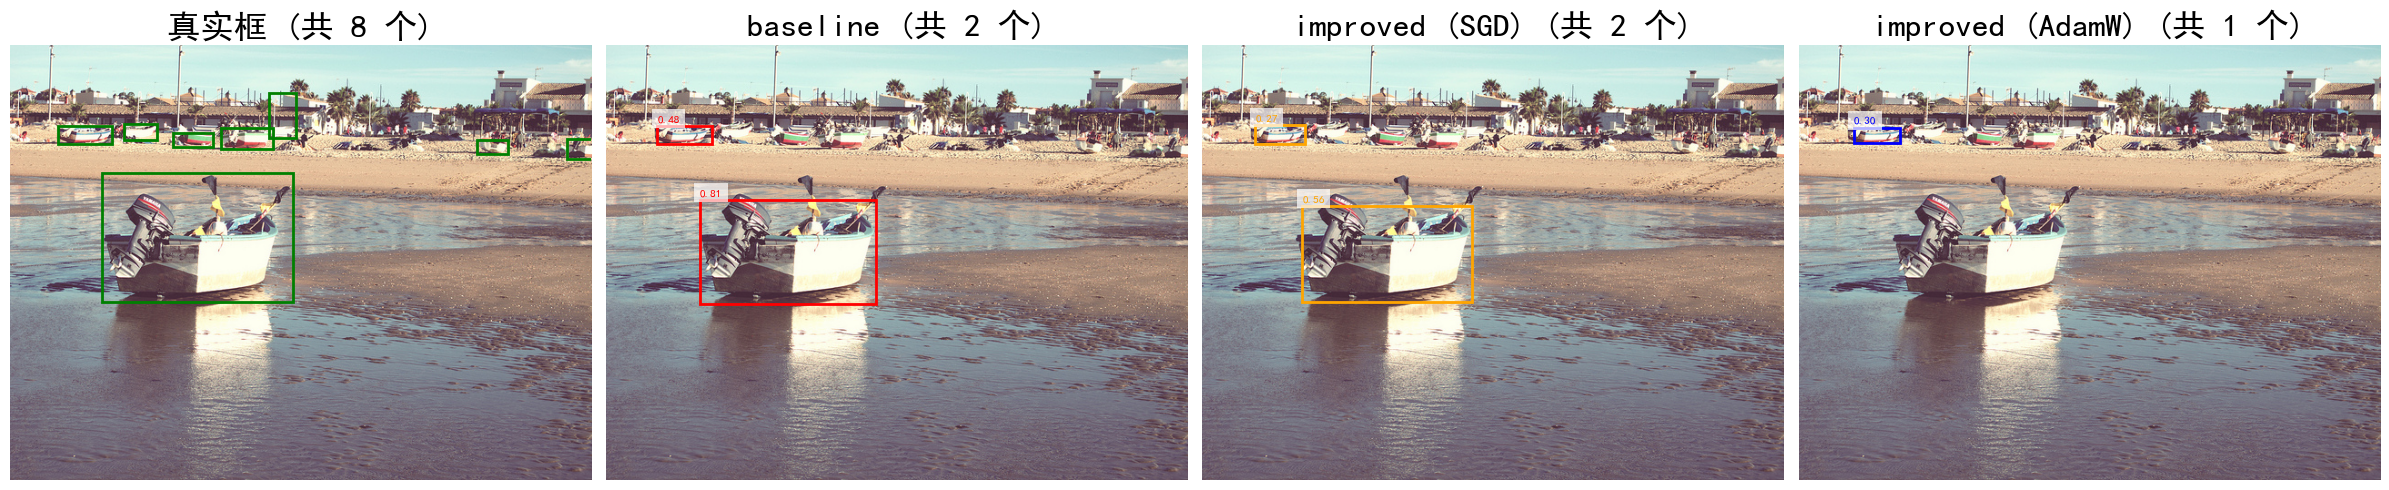


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 3 ships, 11.4ms
Speed: 1.4ms preprocess, 11.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 3 ships, 34.8ms
Speed: 1.3ms preprocess, 34.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 1 ship, 34.7ms
Speed: 1.2ms preprocess, 34.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 512)


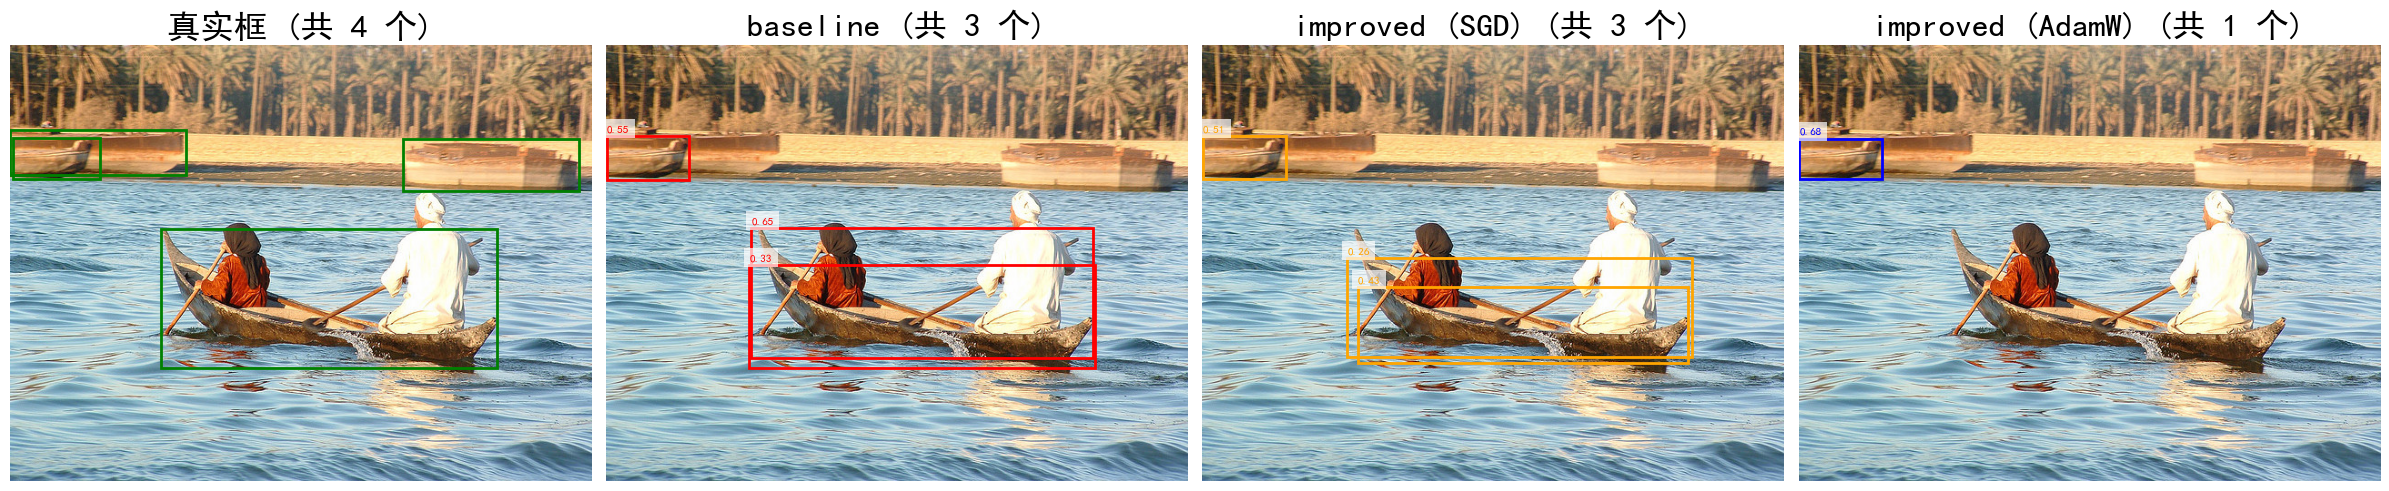


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 15.0ms
Speed: 1.2ms preprocess, 15.0ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 35.8ms
Speed: 1.2ms preprocess, 35.8ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 35.3ms
Speed: 1.3ms preprocess, 35.3ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 512)


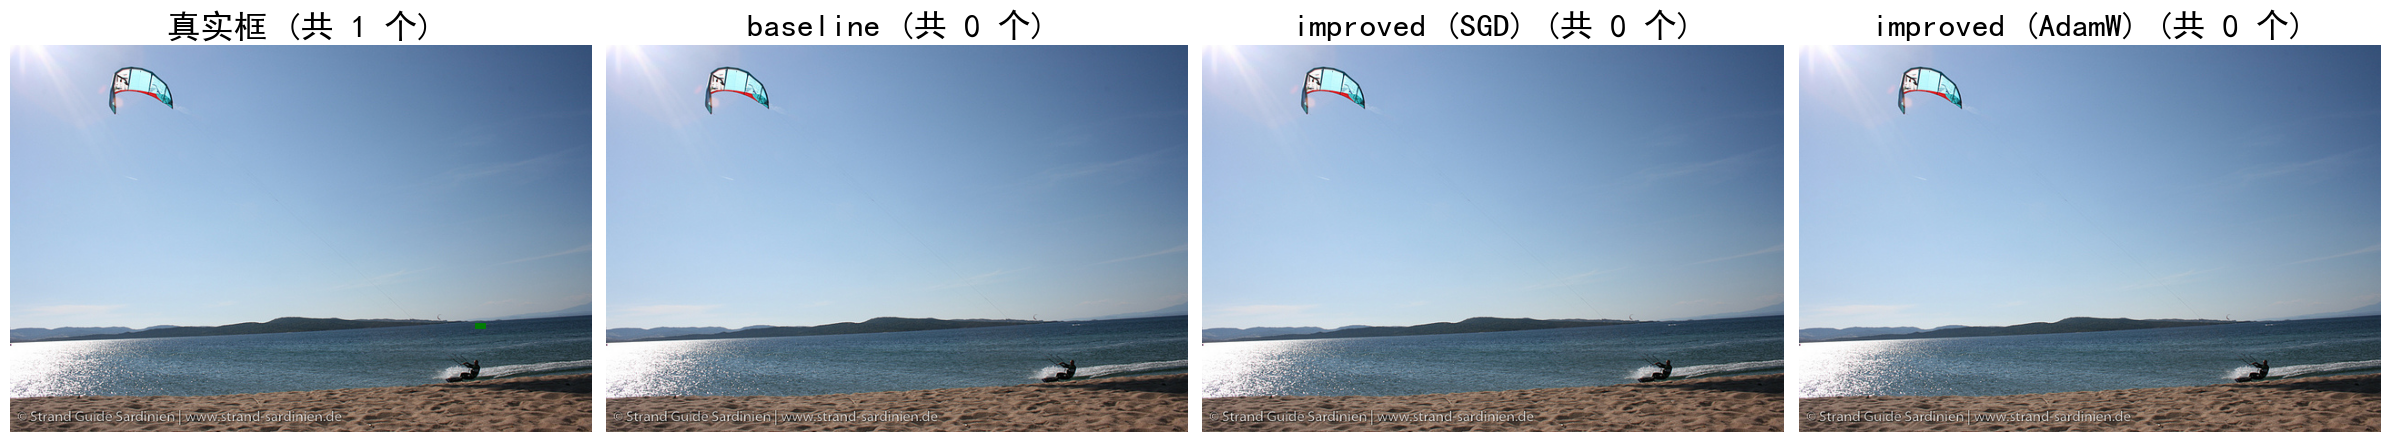


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 6 ships, 12.3ms
Speed: 1.2ms preprocess, 12.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 3 ships, 42.7ms
Speed: 1.3ms preprocess, 42.7ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000004971.jpg: 384x512 1 ship, 43.7ms
Speed: 1.2ms preprocess, 43.7ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 512)


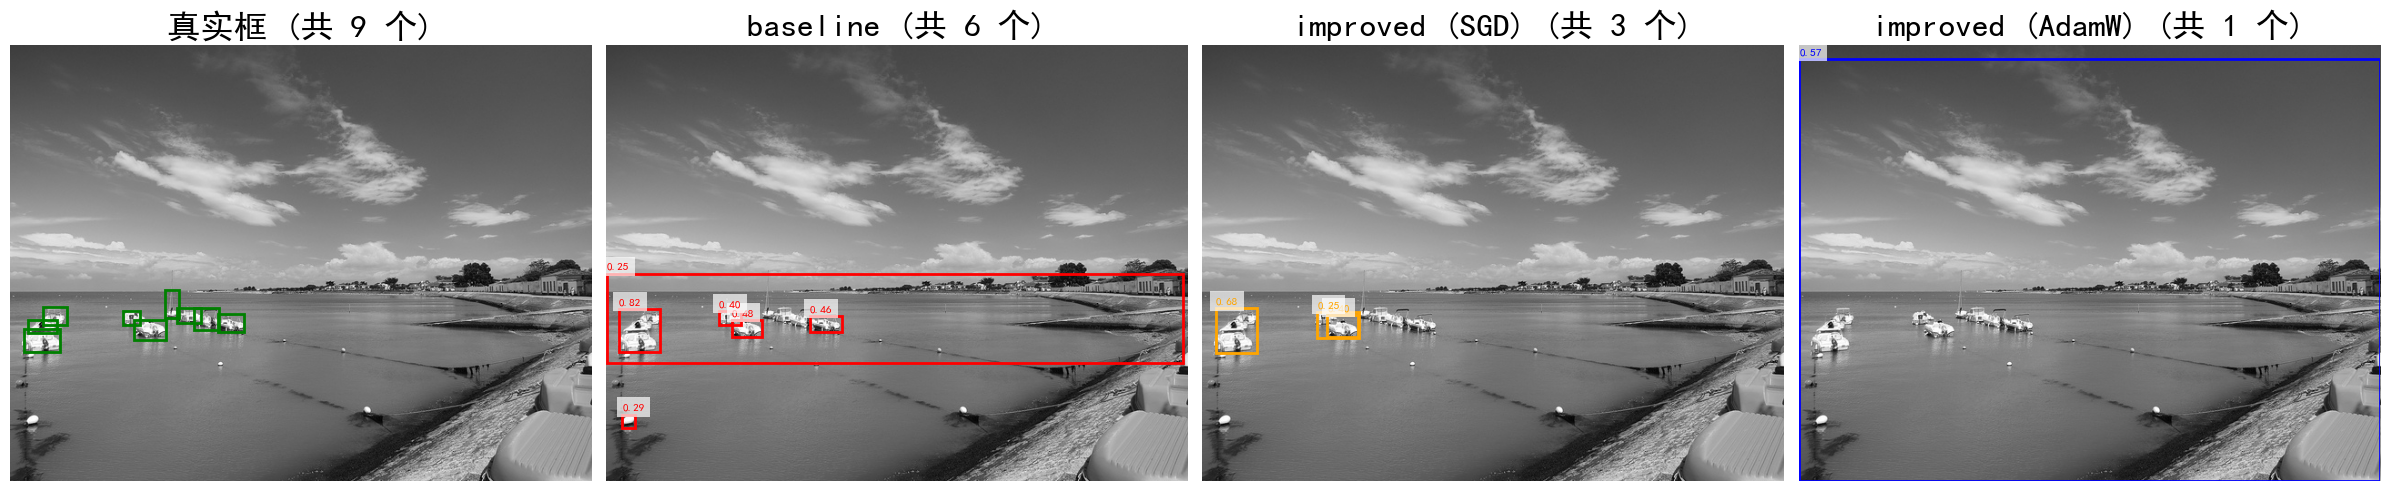

In [5]:
current_dir = Path.cwd()
project_root = current_dir / "ship_detection"
dataset_dir = project_root / "datasets" / "seaships"
test_images_dir = dataset_dir / "images" / "test"
test_labels_dir = dataset_dir / "labels" / "test"
results_dir = project_root / "results"
    
# 加载三个模型
baseline_model = YOLO(results_dir / "yolov11" / "baseline512" / "weights" / "best.pt")
improved_model = YOLO(results_dir / "improved" / "mmsa_con" / "weights" / "best.pt")
improved_adamw_model = YOLO(results_dir / "improved" / "mmsa_512" / "weights" / "best.pt")  
    
models = {
    'baseline': baseline_model,
    'improved (SGD)': improved_model,
    'improved (AdamW)': improved_adamw_model
}
    
# 执行多模型分析（支持任意数量模型）
analysis = analyze_failures_multi(models, test_images_dir, test_labels_dir,
                                    conf_threshold=0.25, iou_threshold=0.5,
                                    max_images=50)
    
# 打印每个模型的统计信息
for name, stat in analysis['stats'].items():
    print(f"\n模型: {name}")
    print(f"  真正例(TP): {stat['tp']}")
    print(f"  假正例(FP): {stat['fp']}")
    print(f"  假负例(FN): {stat['fn']}")
    print(f"  精确率: {stat['precision']:.4f}")
    print(f"  召回率: {stat['recall']:.4f}")
    print(f"  F1分数: {stat['f1']:.4f}")
    
# 筛选对比案例（关注改进模型（SGD）是否有独有错误）
model_names = list(models.keys())
comparison = find_comparison_cases_multi(analysis, model_names, focus_model='improved (SGD)')
    
print(f"\n所有模型都有错误的图像数: {len(comparison['all_error'])}")
print(f"仅 improved (SGD) 有错误的图像数: {len(comparison['only_focus_error'])}")
    
# 可视化：所有模型都有错误的案例（前3张）
print("\n=== 所有模型都有错误的案例 ===")
for img_name in comparison['all_error'][:6]:
    visualize_comparison_multi(models, img_name, test_images_dir, test_labels_dir, conf_threshold=0.25)

print("\n=== 任意模型错误的案例 ===")
for img_name in comparison['any_error'][:5]:
    visualize_comparison_multi(models, img_name, test_images_dir, test_labels_dir, conf_threshold=0.25)
